# Breast Cancer Wisconsin Diagnostic Dataset 
- ➡️This is a classic dataset for training and benchmarking machine learning algorithms.
- ➡️ Biopsy features for classification of 569 malignant (cancer) and benign (not cancer) breast masses.
- ➡️ Features were computationally extracted from digital images of fine needle aspirate biopsy slides. Features correspond to properties of cell nuclei, such as size, shape and regularity. The mean, standard error, and worst value of each of 10 nuclear parameters is reported for a total of 30 features.
 
Available: https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset?resource=download 

### Details
- y. The outcomes. A factor with two levels denoting whether a mass is malignant ("M") or benign ("B").
- x. The predictors. A matrix with the mean, standard error and worst value of each of 10 nuclear measurements on the slide, for 30 total features per biopsy:
    - radius. Nucleus radius (mean of distances from center to points on perimeter).
    - texture. Nucleus texture (standard deviation of grayscale values).
    - perimeter. Nucleus perimeter.
    - area. Nucleus area.
    - smoothness. Nucleus smoothness (local variation in radius lengths).
    -  compactness. Nucleus compactness (perimeter^2/area - 1).
    - concavity, Nucleus concavity (severity of concave portions of the contour).
    - concave_pts. Number of concave portions of the nucleus contour.
    - symmetry. Nucleus symmetry.
    - fractal_dim. Nucleus fractal dimension ("coastline approximation" -1).

|Column	| Description|
|---------|-------------|
|x.radius_mean	|Mean radius of the tumor cells
|x.texture_mean	|Mean texture of the tumor cells
|x.perimeter_mean	|Mean perimeter of the tumor cells
|x.area_mean	|Mean area of the tumor cells
|x.smoothness_mean	|Mean smoothness of the tumor cells
|x.compactness_mean	|Mean compactness of the tumor cells
|x.concavity_mean	|Mean concavity of the tumor cells
|x.concave_points_mean	|Mean number of concave portions of the contour of the tumor cells
|x.symmetry_mean	|Mean symmetry of the tumor cells
|x.fractal_dimension_mean	|Mean "coastline approximation" of the tumor cells
|x.radius_se	|Standard error of the radius of the tumor cells
|x.texture_se	|Standard error of the texture of the tumor cells
|x.perimeter_se	|Standard error of the perimeter of the tumor cells
|x.area_se	|Standard error of the area of the tumor cells
|x.smoothness_se	|Standard error of the smoothness of the tumor cells
|x.compactness_se	|Standard error of the compactness of the tumor cells
|x.concavity_se	|Standard error of the concavity of the tumor cells
|x.concave_points_se	|Standard error of the number of concave portions of the contour of the tumor cells
|x.symmetry_se	|Standard error of the symmetry of the tumor cells
|x.fractal_dimension_se	|Standard error of the "coastline approximation" of the tumor cells
|x.radius_worst	|Worst (largest) radius of the tumor cells
|x.texture_worst	|Worst (most severe) texture of the tumor cells
|x.perimeter_worst	|Worst (largest) perimeter of the tumor cells
|x.area_worst	|Worst (largest) area of the tumor cells
|x.smoothness_worst	|Worst (most severe) smoothness of the tumor cells
|x.compactness_worst	|Worst (most severe) compactness of the tumor cells
|x.concavity_worst	|Worst (most severe) concavity of the tumor cells
|x.concave_points_worst	|Worst (most severe) number of concave portions of the contour of the tumor cells
|x.symmetry_worst	|Worst (most severe) symmetry of the tumor cells
|x.fractal_dimension_worst	|Worst (most severe) "coastline approximation" of the tumor cells
|y	target

Here in this notebook it ill be the Exploratory Data Analysis (EDA)

In [1]:
#libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data from original clean database

1.1. Load the data

In [2]:
df = pd.read_csv('data/brca_clean.csv')

1.2. Basic information about the dataset

In [3]:
print("--- Dataset Info ---")
print(df.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   x.radius_mean        569 non-null    float64
 1   x.texture_mean       569 non-null    float64
 2   x.perimeter_mean     569 non-null    float64
 3   x.area_mean          569 non-null    float64
 4   x.smoothness_mean    569 non-null    float64
 5   x.compactness_mean   569 non-null    float64
 6   x.concavity_mean     569 non-null    float64
 7   x.concave_pts_mean   569 non-null    float64
 8   x.symmetry_mean      569 non-null    float64
 9   x.fractal_dim_mean   569 non-null    float64
 10  x.radius_se          569 non-null    float64
 11  x.texture_se         569 non-null    float64
 12  x.perimeter_se       569 non-null    float64
 13  x.area_se            569 non-null    float64
 14  x.smoothness_se      569 non-null    float64
 15  x.compactness_se   

1.3. Statistical summary

In [4]:
print("--- Statistical Summary ---")
print(df.describe())

--- Statistical Summary ---
       x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
count     569.000000      569.000000        569.000000   569.000000   
mean       14.127292       19.289649         91.969033   654.889104   
std         3.524049        4.301036         24.298981   351.914129   
min         6.981000        9.710000         43.790000   143.500000   
25%        11.700000       16.170000         75.170000   420.300000   
50%        13.370000       18.840000         86.240000   551.100000   
75%        15.780000       21.800000        104.100000   782.700000   
max        28.110000       39.280000        188.500000  2501.000000   

       x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
count         569.000000          569.000000        569.000000   
mean            0.096360            0.104341          0.088799   
std             0.014064            0.052813          0.079720   
min             0.052630            0.019380          0.000000   
25

1.4. Check the balance of our target (y)

In [5]:
print("--- Target Variable Distribution ---")
print(df['y'].value_counts())

--- Target Variable Distribution ---
y
0    357
1    212
Name: count, dtype: int64


1.5. Correlation (Heatmap)

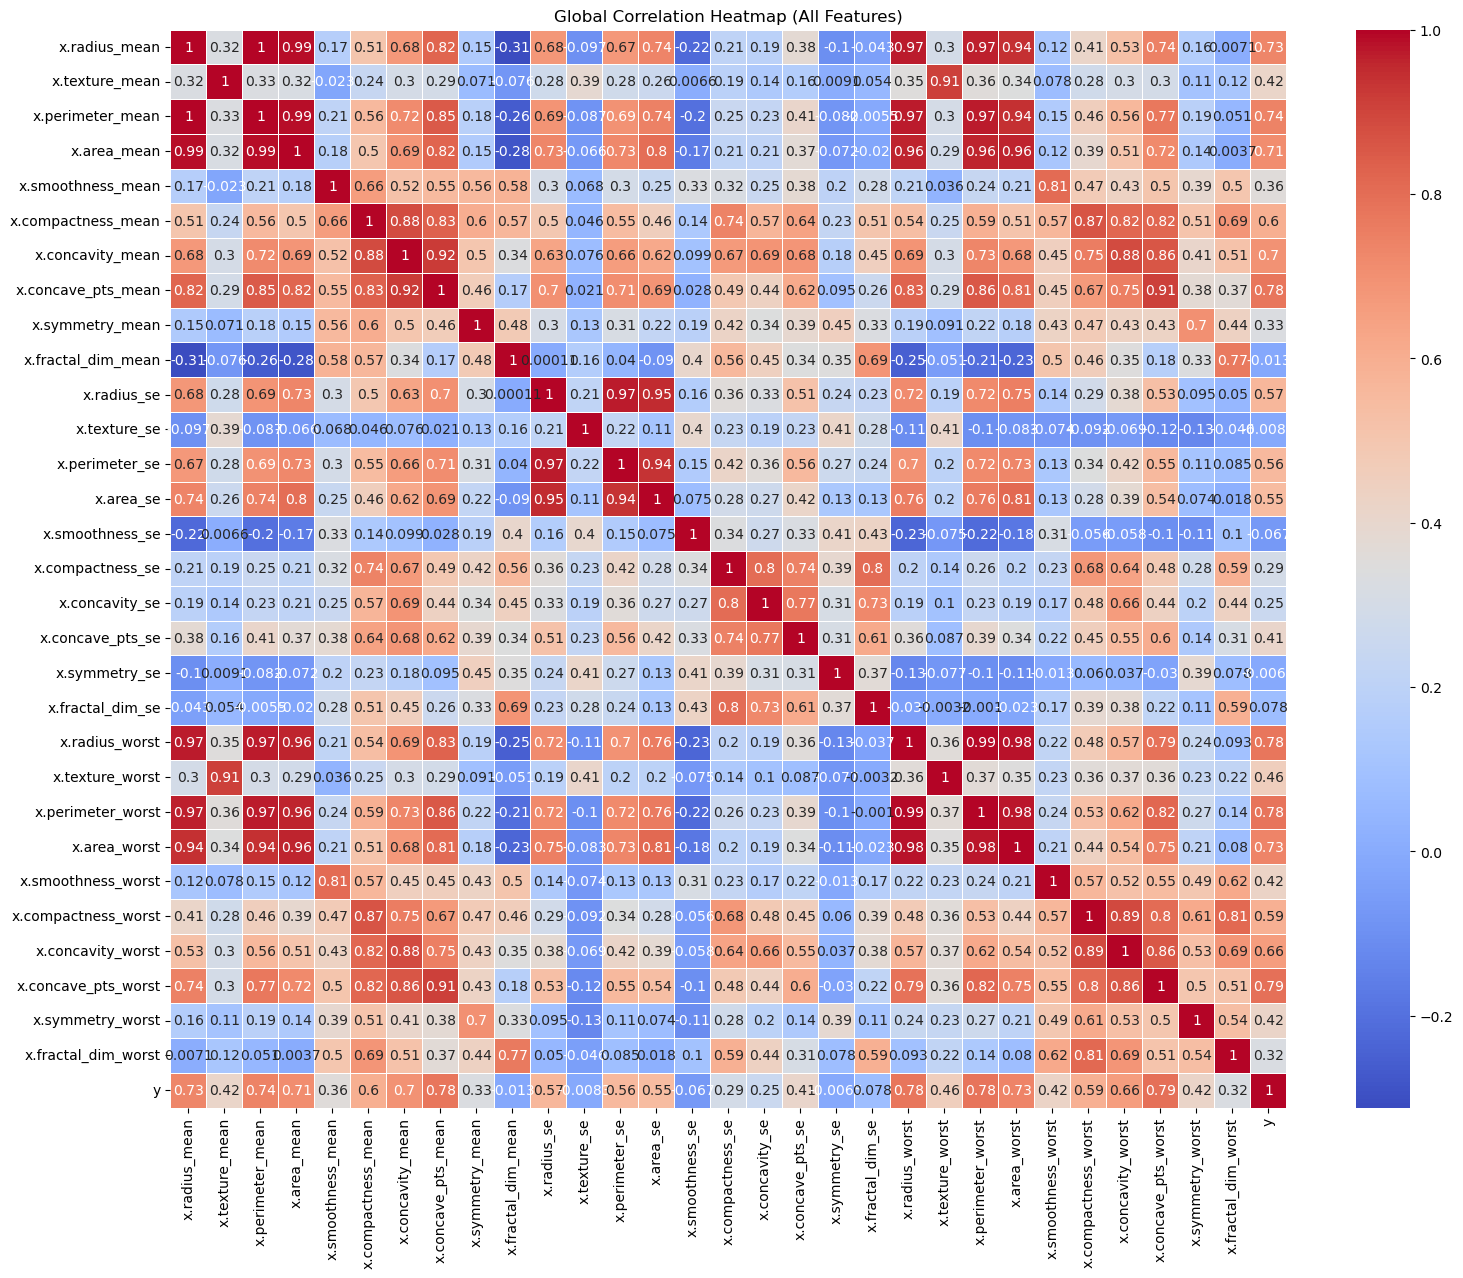

In [6]:
plt.figure(figsize=(18, 14))

# Calculate the correlation matrix for all features
correlation_matrix_full = df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Global Correlation Heatmap (All Features)')
plt.show()

1.6. Visualization - boxplot

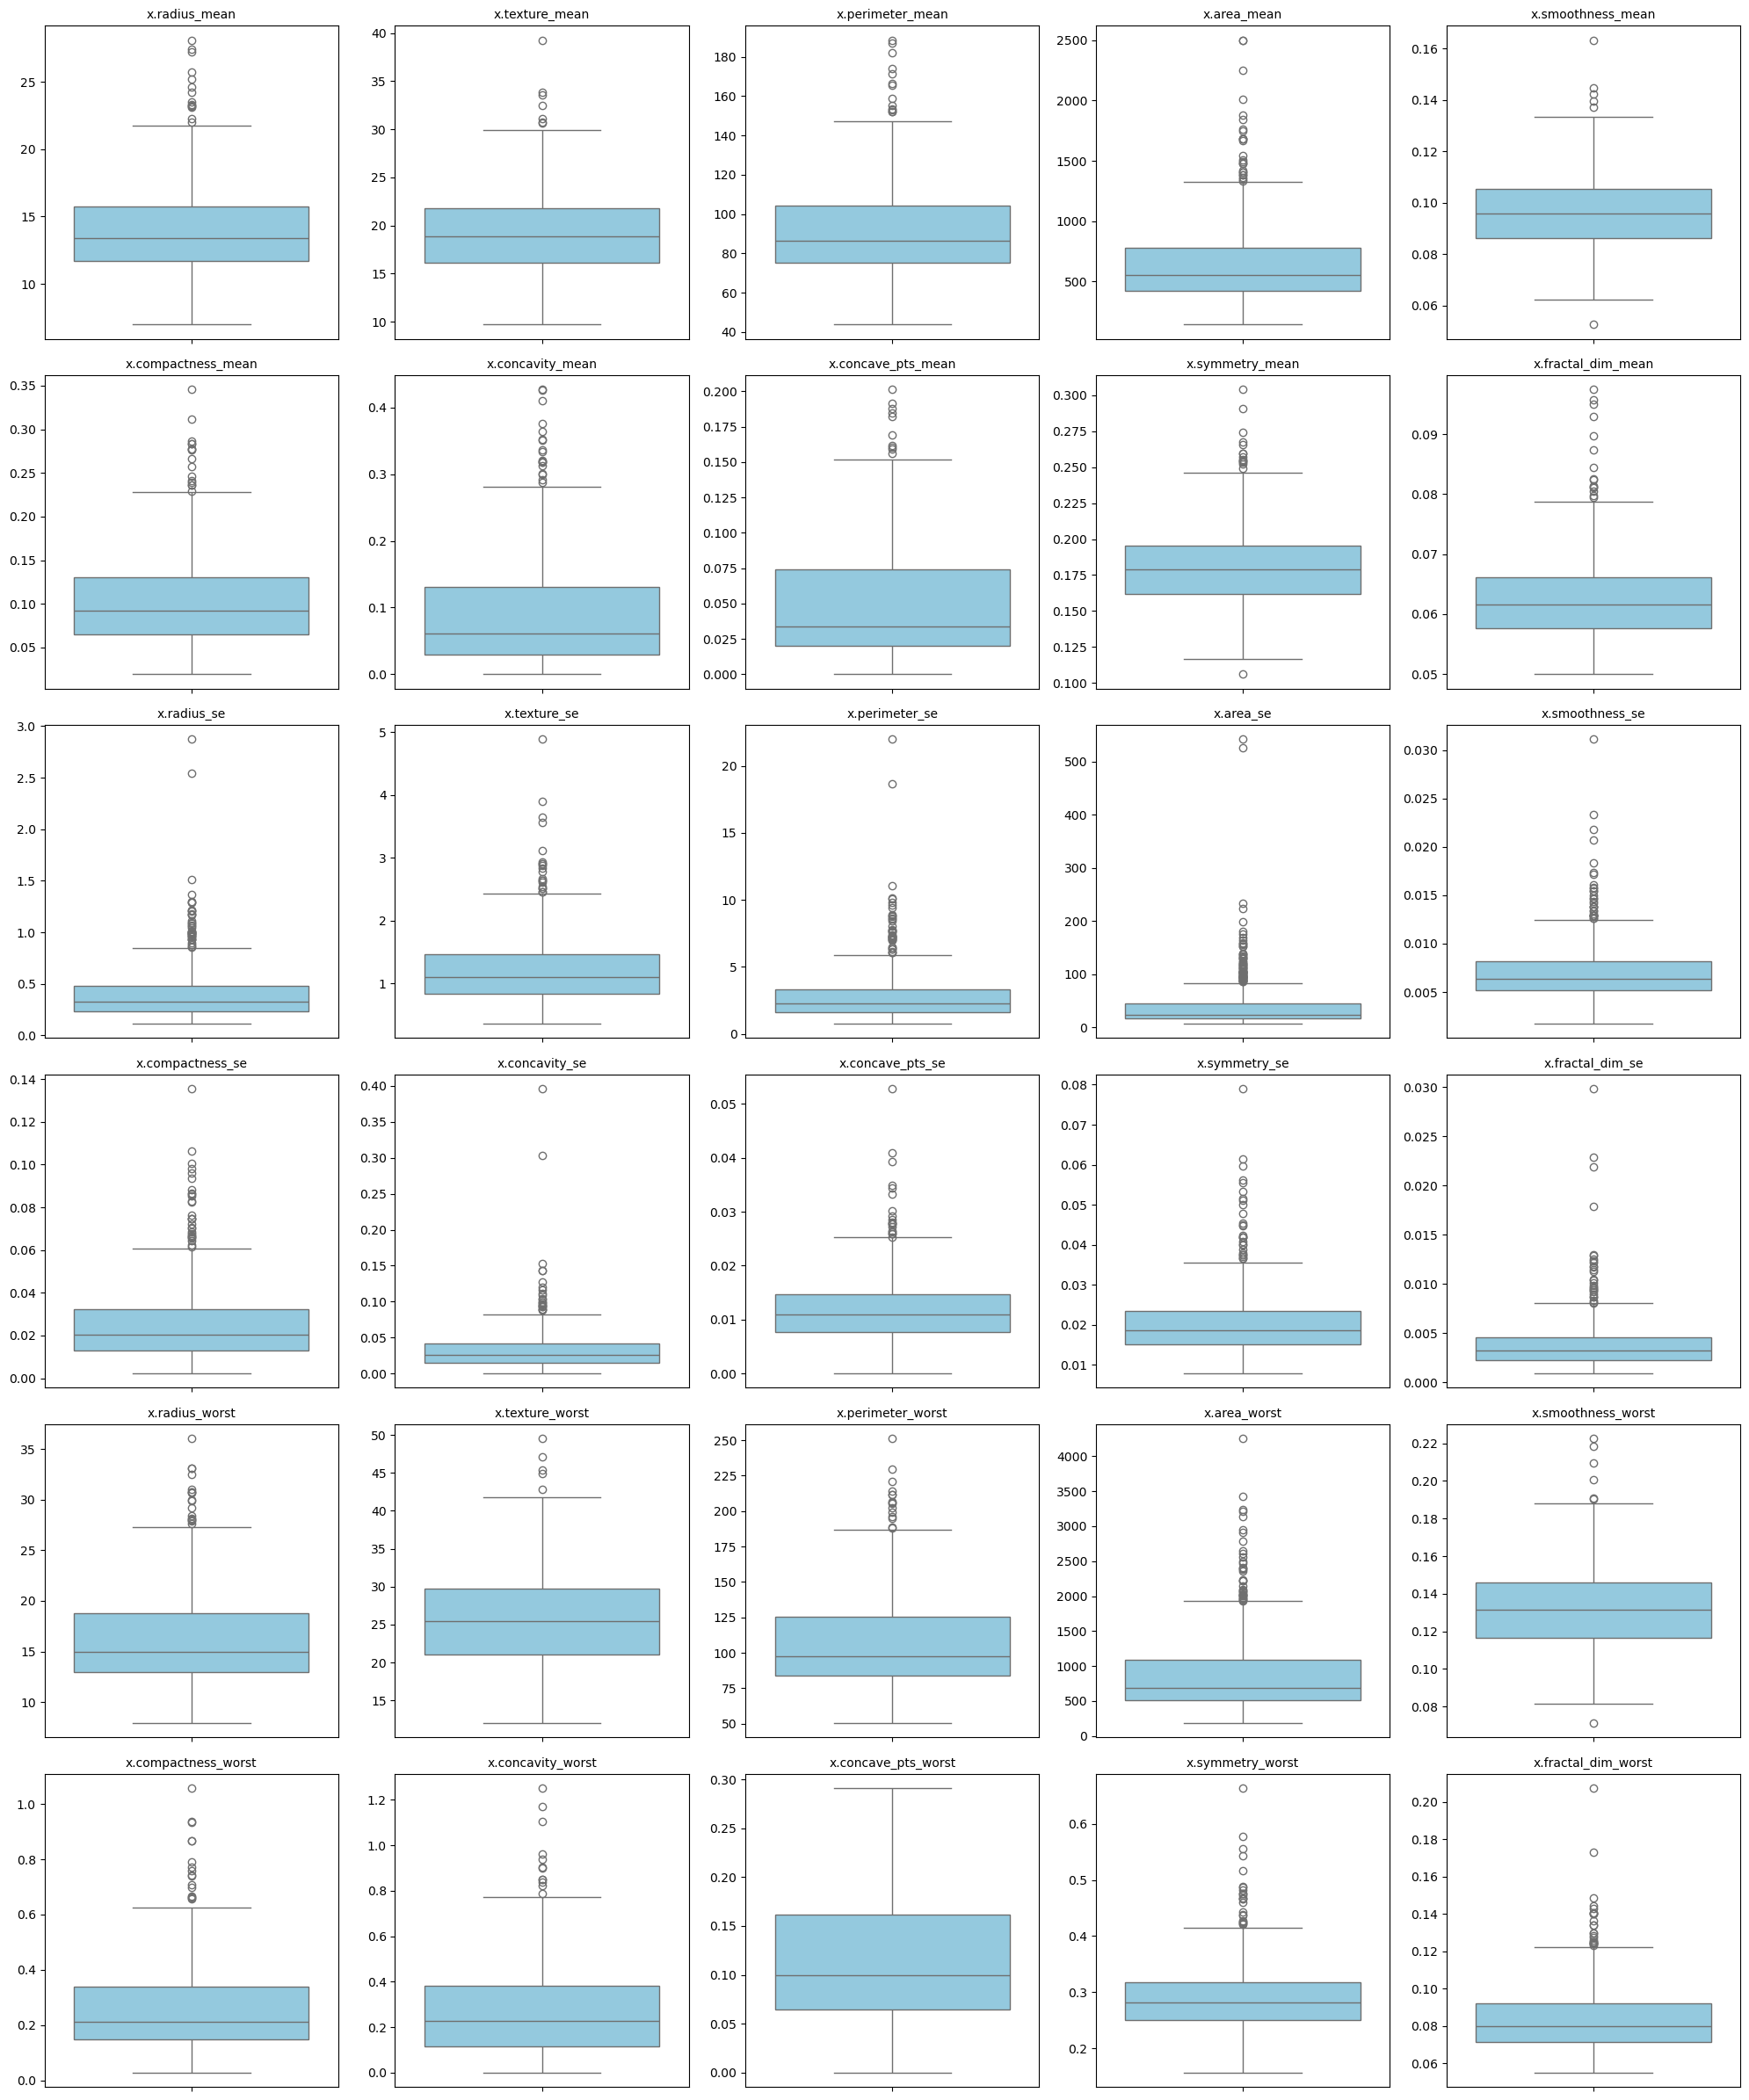

In [7]:
features = [col for col in df.columns if col != 'y']

fig, axes = plt.subplots(6, 5, figsize=(20, 24))
axes = axes.flatten() 
for i, feature in enumerate(features):
    sns.boxplot(y=df[feature], ax=axes[i], color='skyblue')
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\lugon\AppData\Local\Temp\ipykernel_15712\3586692045.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='Pastel2')


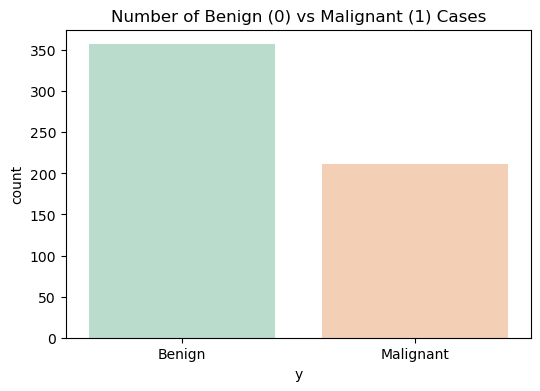

y
0    357
1    212
Name: count, dtype: int64

In [8]:
# Number of Benign (0) vs Malignant (1)

plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='Pastel2')
plt.title('Number of Benign (0) vs Malignant (1) Cases')
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.show()

df['y'].value_counts()

## 2. Data from Model 3 dataset: only mean columns

2.1. Load the data

In [9]:
df_mean = pd.read_csv('data/brca_clean_mean.csv')

2.2. Basic information about the dataset

In [10]:
print("--- Dataset Info ---")
print(df_mean.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   x.radius_mean       569 non-null    float64
 1   x.texture_mean      569 non-null    float64
 2   x.perimeter_mean    569 non-null    float64
 3   x.area_mean         569 non-null    float64
 4   x.smoothness_mean   569 non-null    float64
 5   x.compactness_mean  569 non-null    float64
 6   x.concavity_mean    569 non-null    float64
 7   x.concave_pts_mean  569 non-null    float64
 8   x.symmetry_mean     569 non-null    float64
 9   x.fractal_dim_mean  569 non-null    float64
 10  y                   569 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 49.0 KB
None


2.3. Statistical summary

In [11]:
print("--- Statistical Summary ---")
print(df_mean.describe())

--- Statistical Summary ---
       x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
count     569.000000      569.000000        569.000000   569.000000   
mean       14.127292       19.289649         91.969033   654.889104   
std         3.524049        4.301036         24.298981   351.914129   
min         6.981000        9.710000         43.790000   143.500000   
25%        11.700000       16.170000         75.170000   420.300000   
50%        13.370000       18.840000         86.240000   551.100000   
75%        15.780000       21.800000        104.100000   782.700000   
max        28.110000       39.280000        188.500000  2501.000000   

       x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
count         569.000000          569.000000        569.000000   
mean            0.096360            0.104341          0.088799   
std             0.014064            0.052813          0.079720   
min             0.052630            0.019380          0.000000   
25

2.4. Check the balance of our target (y)

In [12]:
print("--- Target Variable Distribution ---")
print(df_mean['y'].value_counts())

--- Target Variable Distribution ---
y
0    357
1    212
Name: count, dtype: int64


2.5. Correlation (Heatmap)

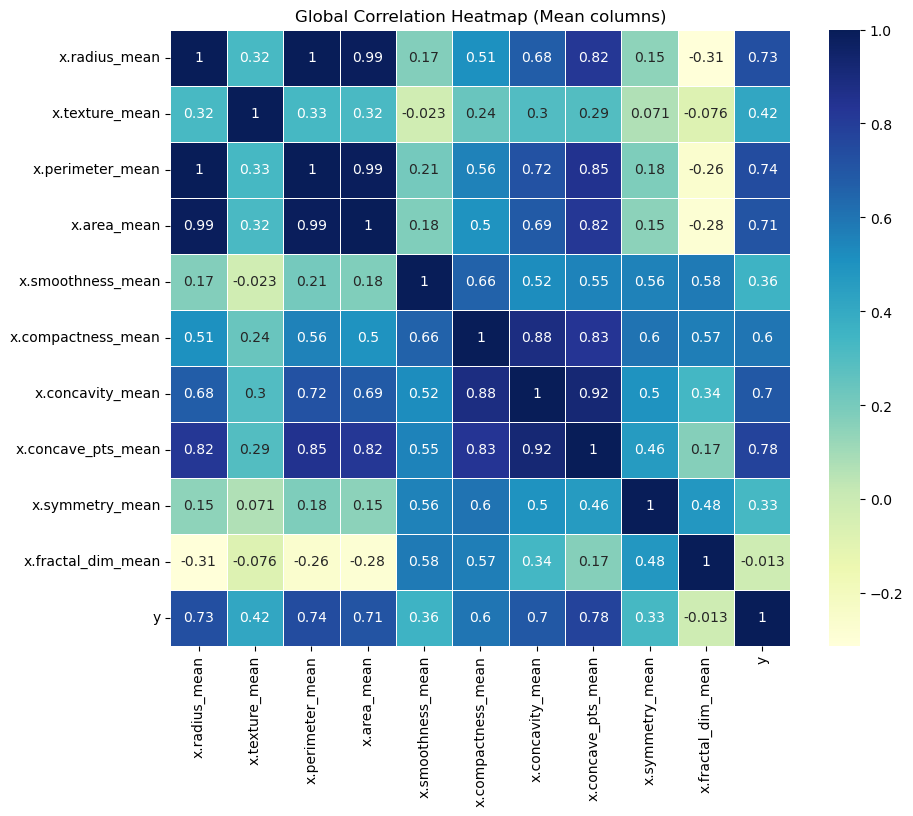

In [13]:
plt.figure(figsize=(10, 8))

# Calculate the correlation matrix for all features
correlation_matrix_full = df_mean.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix_full, annot=True, cmap='YlGnBu', linewidths=0.5)
plt.title('Global Correlation Heatmap (Mean columns)')
plt.show()

2.6. Visualization - boxplot

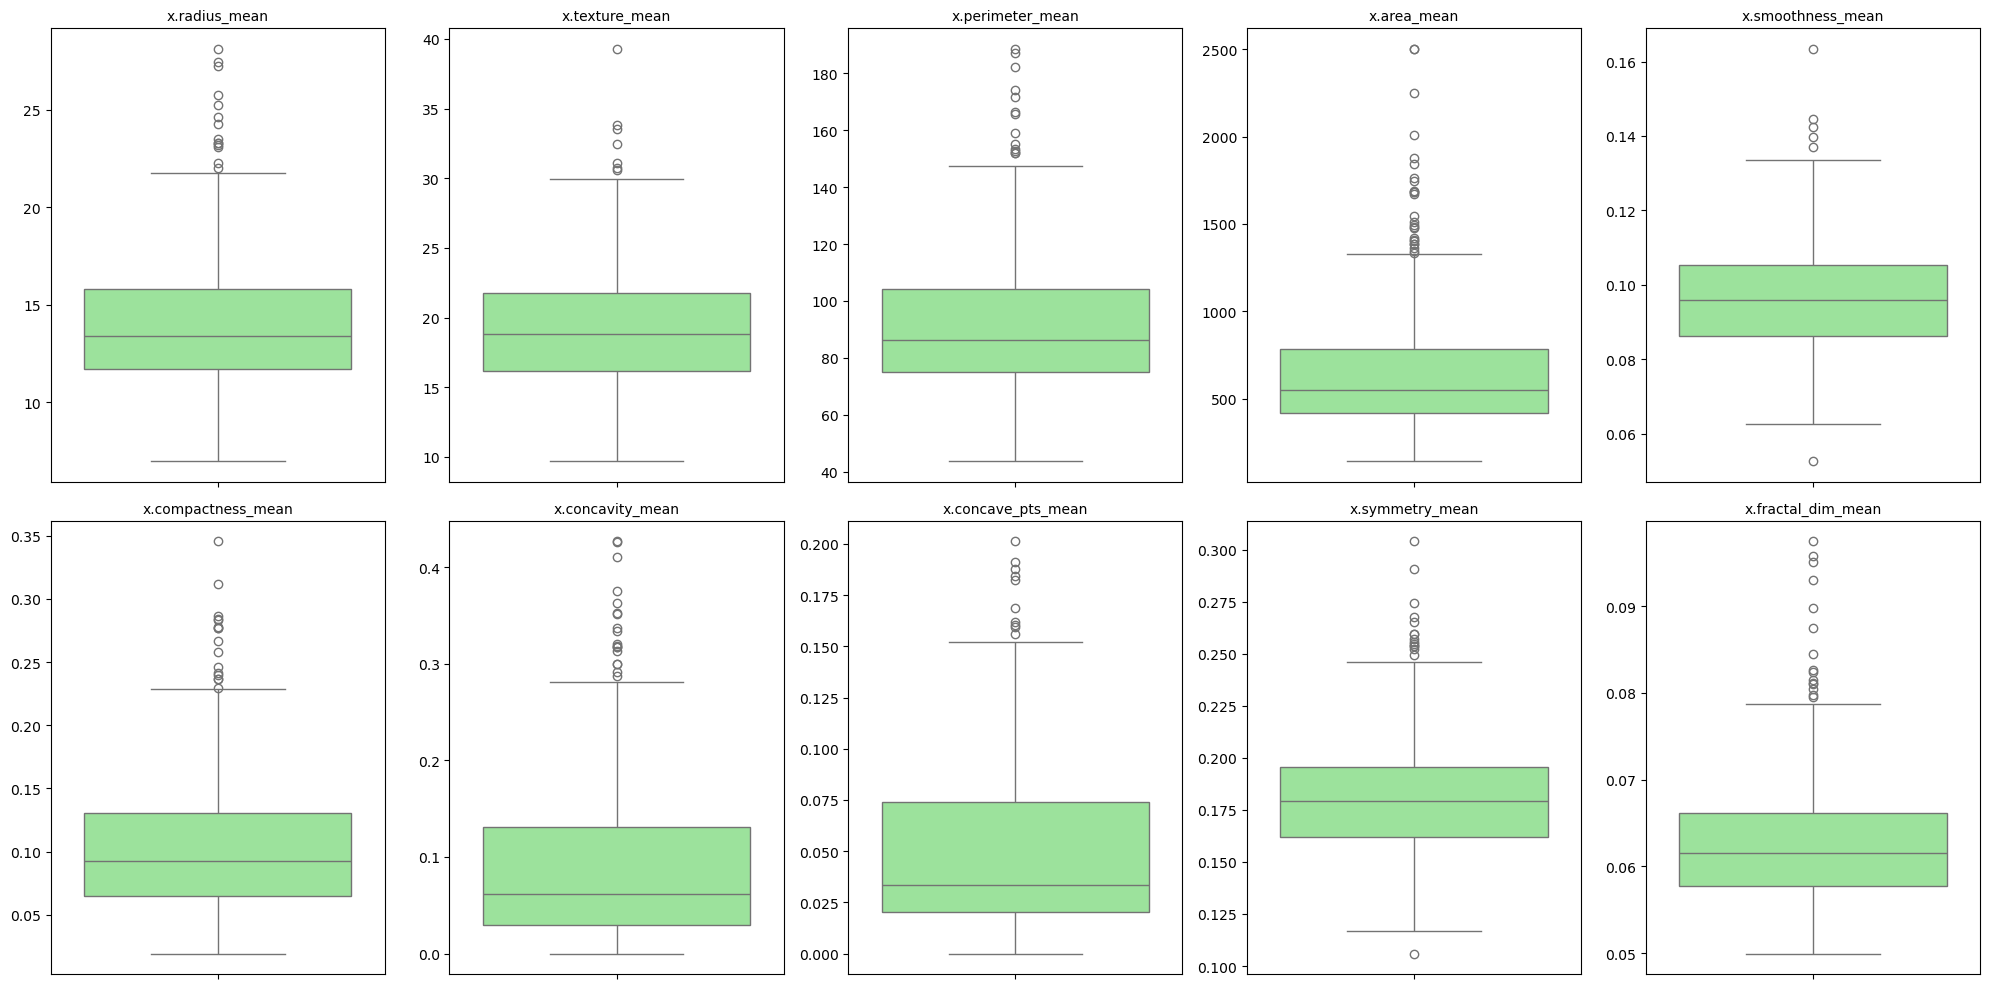

In [14]:
features = [col for col in df_mean.columns if col != 'y']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten() 
for i, feature in enumerate(features):
    sns.boxplot(y=df[feature], ax=axes[i], color='lightgreen')
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## 3. Data from Model 4 dataset: only se columns

3.1. Load the data

In [15]:
df_se = pd.read_csv('data/brca_clean_se.csv')

3.2. Basic information about the dataset

In [16]:
print("--- Dataset Info ---")
print(df_se.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   x.radius_se       569 non-null    float64
 1   x.texture_se      569 non-null    float64
 2   x.perimeter_se    569 non-null    float64
 3   x.area_se         569 non-null    float64
 4   x.smoothness_se   569 non-null    float64
 5   x.compactness_se  569 non-null    float64
 6   x.concavity_se    569 non-null    float64
 7   x.concave_pts_se  569 non-null    float64
 8   x.symmetry_se     569 non-null    float64
 9   x.fractal_dim_se  569 non-null    float64
 10  y                 569 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 49.0 KB
None


3.3. Statistical summary

In [17]:
print("--- Statistical Summary ---")
print(df_se.describe())

--- Statistical Summary ---
       x.radius_se  x.texture_se  x.perimeter_se   x.area_se  x.smoothness_se  \
count   569.000000    569.000000      569.000000  569.000000       569.000000   
mean      0.405172      1.216853        2.866059   40.337079         0.007041   
std       0.277313      0.551648        2.021855   45.491006         0.003003   
min       0.111500      0.360200        0.757000    6.802000         0.001713   
25%       0.232400      0.833900        1.606000   17.850000         0.005169   
50%       0.324200      1.108000        2.287000   24.530000         0.006380   
75%       0.478900      1.474000        3.357000   45.190000         0.008146   
max       2.873000      4.885000       21.980000  542.200000         0.031130   

       x.compactness_se  x.concavity_se  x.concave_pts_se  x.symmetry_se  \
count        569.000000      569.000000        569.000000     569.000000   
mean           0.025478        0.031894          0.011796       0.020542   
std           

3.4. Check the balance of our target (y)

In [18]:
print("--- Target Variable Distribution ---")
print(df_se['y'].value_counts())

--- Target Variable Distribution ---
y
0    357
1    212
Name: count, dtype: int64


3.5. Correlation (Heatmap)

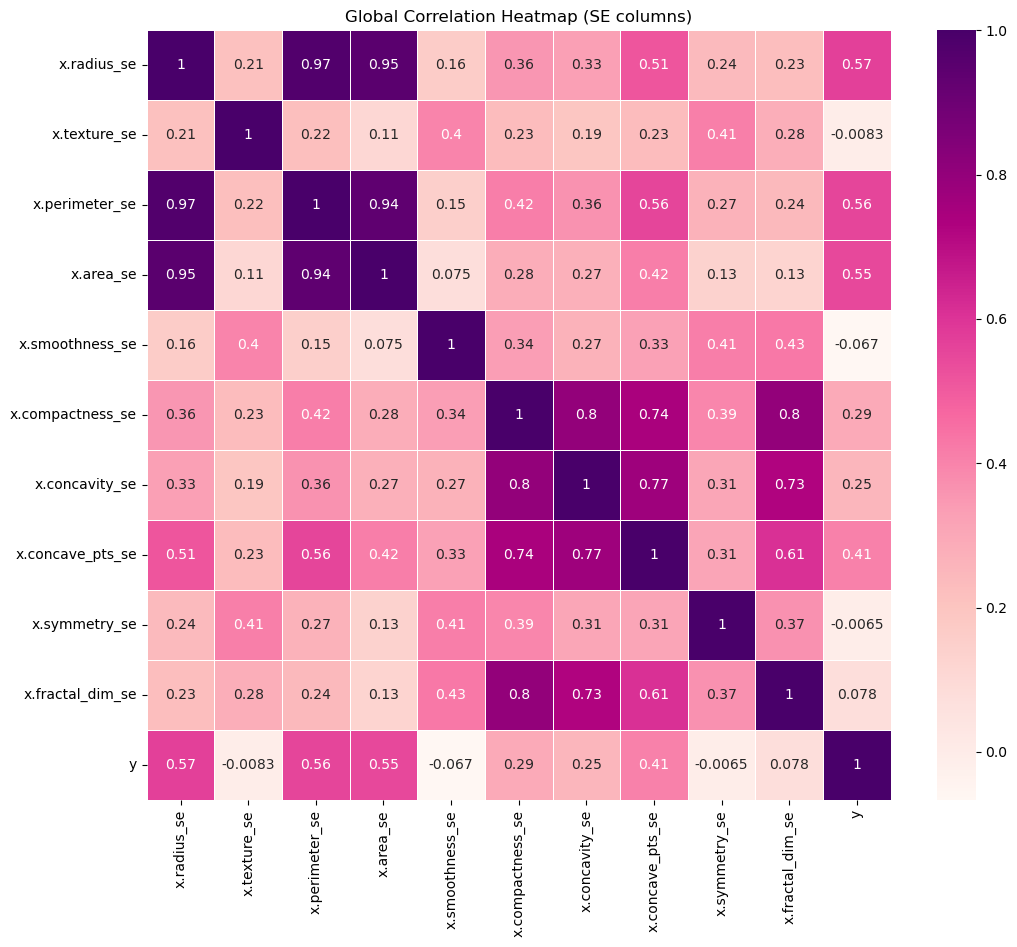

In [19]:
plt.figure(figsize=(12, 10))

# Calculate the correlation matrix for all features
correlation_matrix_full = df_se.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix_full, annot=True, cmap='RdPu', linewidths=0.5)
plt.title('Global Correlation Heatmap (SE columns)')
plt.show()

3.6. Visualization - boxplot

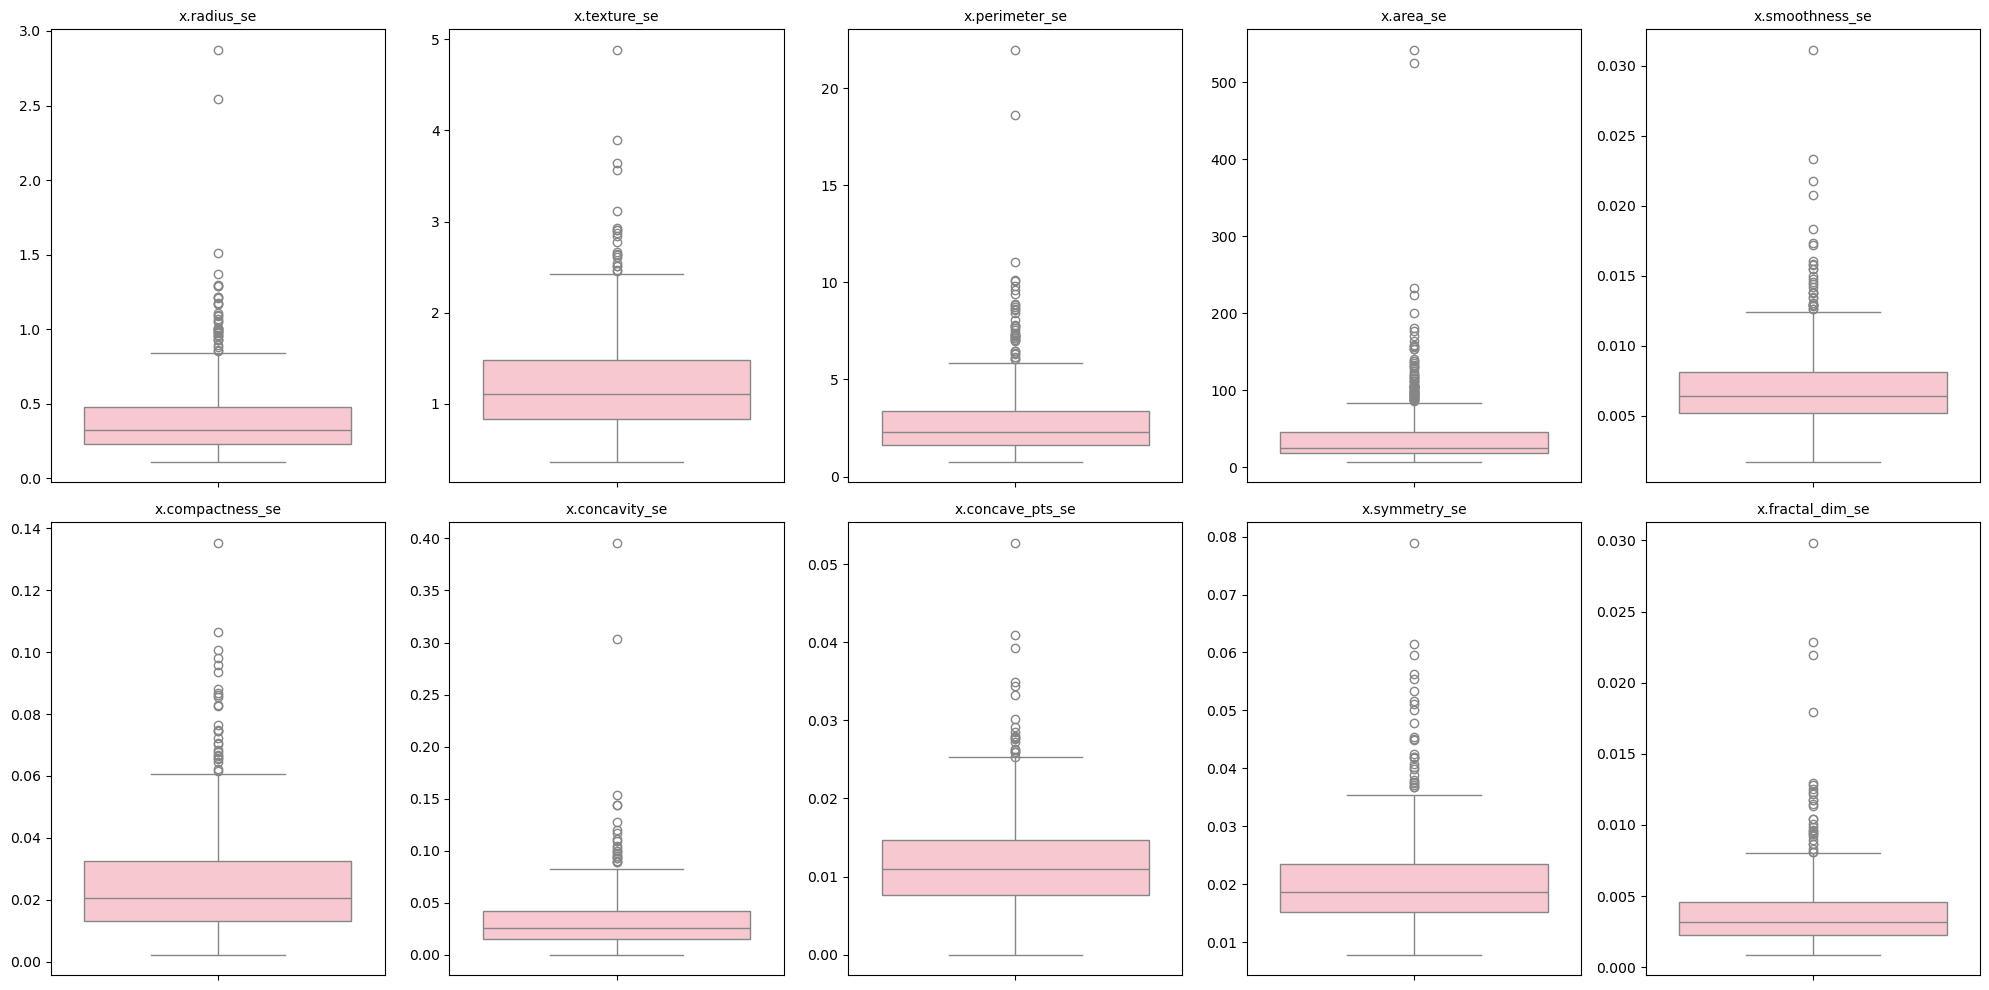

In [20]:
features = [col for col in df_se.columns if col != 'y']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten() 
for i, feature in enumerate(features):
    sns.boxplot(y=df[feature], ax=axes[i], color='pink')
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## 4. Top 4 features from "mean" data

4.1. Load the data

In [21]:
df_top4_mean = pd.read_csv('data/brca_clean_top4_mean.csv')

4.2. Basic information about the dataset

In [22]:
print("--- Dataset Info ---")
print(df_top4_mean.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   x.concave_pts_mean  569 non-null    float64
 1   x.radius_mean       569 non-null    float64
 2   x.texture_mean      569 non-null    float64
 3   x.compactness_mean  569 non-null    float64
 4   y                   569 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 22.4 KB
None


4.3. Statistical summary

In [23]:
print("--- Statistical Summary ---")
print(df_top4_mean.describe())

--- Statistical Summary ---
       x.concave_pts_mean  x.radius_mean  x.texture_mean  x.compactness_mean  \
count          569.000000     569.000000      569.000000          569.000000   
mean             0.048919      14.127292       19.289649            0.104341   
std              0.038803       3.524049        4.301036            0.052813   
min              0.000000       6.981000        9.710000            0.019380   
25%              0.020310      11.700000       16.170000            0.064920   
50%              0.033500      13.370000       18.840000            0.092630   
75%              0.074000      15.780000       21.800000            0.130400   
max              0.201200      28.110000       39.280000            0.345400   

                y  
count  569.000000  
mean     0.372583  
std      0.483918  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      1.000000  


4.4. Check the balance of our target (y)

In [24]:
print("--- Target Variable Distribution ---")
print(df_top4_mean['y'].value_counts())

--- Target Variable Distribution ---
y
0    357
1    212
Name: count, dtype: int64


4.5. Correlation (Heatmap)

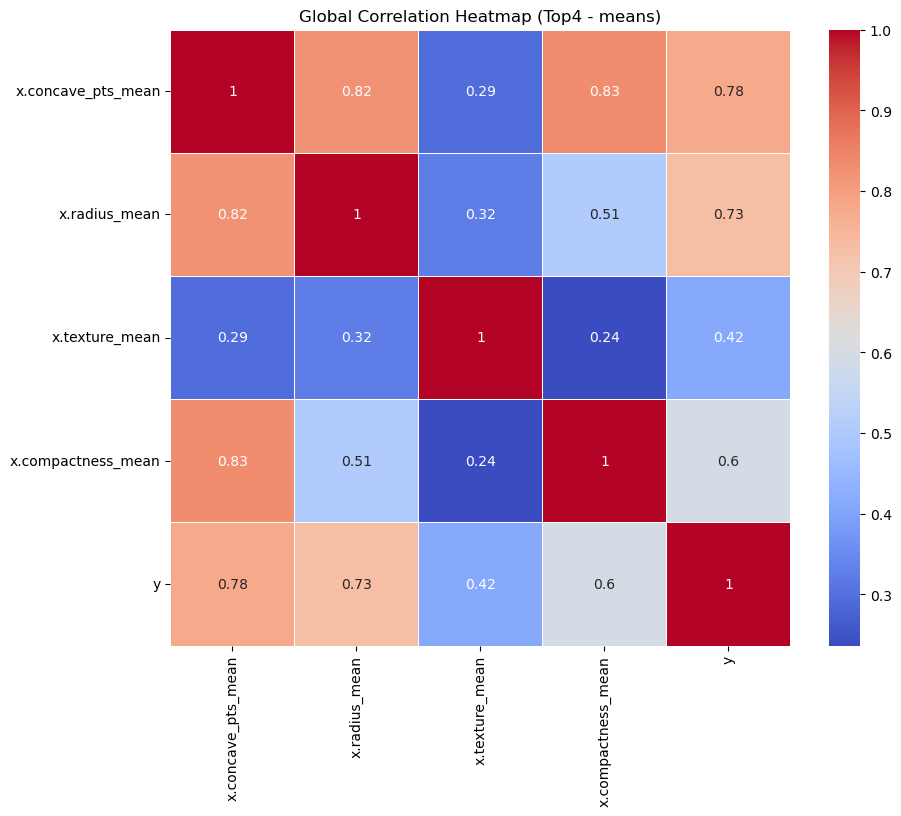

In [25]:
plt.figure(figsize=(10, 8))

# Calculate the correlation matrix for all features
correlation_matrix_full = df_top4_mean.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Global Correlation Heatmap (Top4 - means)')
plt.show()

4.6. Visualization - boxplot

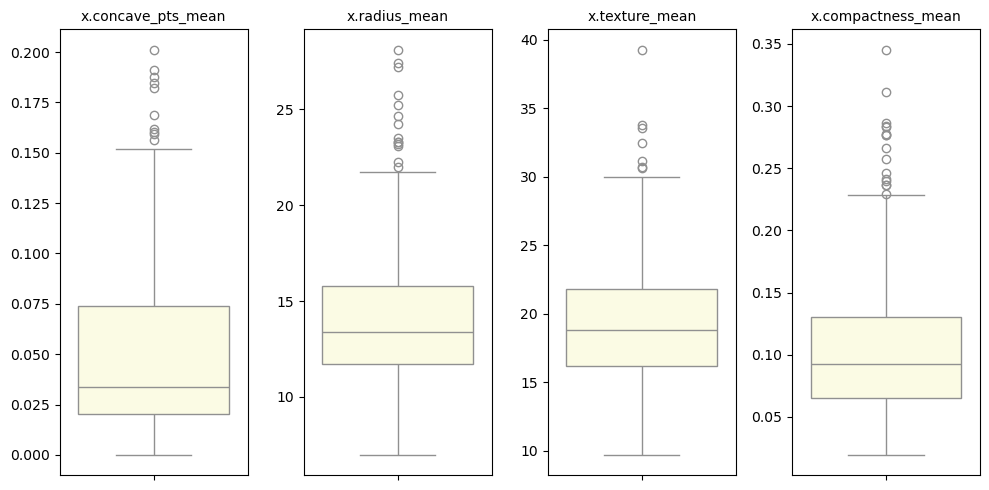

In [26]:
features = [col for col in df_top4_mean.columns if col != 'y']

fig, axes = plt.subplots(1, 4, figsize=(10, 5))
axes = axes.flatten() 
for i, feature in enumerate(features):
    sns.boxplot(y=df[feature], ax=axes[i], color='lightyellow')
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Top 10 features from clean baseline data

5.1. Load the data

In [27]:
df_top10 = pd.read_csv('data/brca_clean_top10.csv')

5.2. Basic information about the dataset

In [28]:
print("--- Dataset Info ---")
print(df_top10.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   x.concave_pts_worst  569 non-null    float64
 1   x.radius_worst       569 non-null    float64
 2   x.perimeter_mean     569 non-null    float64
 3   x.concavity_mean     569 non-null    float64
 4   x.compactness_worst  569 non-null    float64
 5   x.radius_se          569 non-null    float64
 6   x.texture_worst      569 non-null    float64
 7   x.smoothness_worst   569 non-null    float64
 8   x.texture_mean       569 non-null    float64
 9   x.symmetry_worst     569 non-null    float64
 10  y                    569 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 49.0 KB
None


5.3. Statistical summary

In [29]:
print("--- Statistical Summary ---")
print(df_top10.describe())

--- Statistical Summary ---
       x.concave_pts_worst  x.radius_worst  x.perimeter_mean  \
count           569.000000      569.000000        569.000000   
mean              0.114606       16.269190         91.969033   
std               0.065732        4.833242         24.298981   
min               0.000000        7.930000         43.790000   
25%               0.064930       13.010000         75.170000   
50%               0.099930       14.970000         86.240000   
75%               0.161400       18.790000        104.100000   
max               0.291000       36.040000        188.500000   

       x.concavity_mean  x.compactness_worst  x.radius_se  x.texture_worst  \
count        569.000000           569.000000   569.000000       569.000000   
mean           0.088799             0.254265     0.405172        25.677223   
std            0.079720             0.157336     0.277313         6.146258   
min            0.000000             0.027290     0.111500        12.020000   
25%  

5.4. Check the balance of our target (y)

In [30]:
print("--- Target Variable Distribution ---")
print(df_top10['y'].value_counts())

--- Target Variable Distribution ---
y
0    357
1    212
Name: count, dtype: int64


5.5. Correlation (Heatmap)

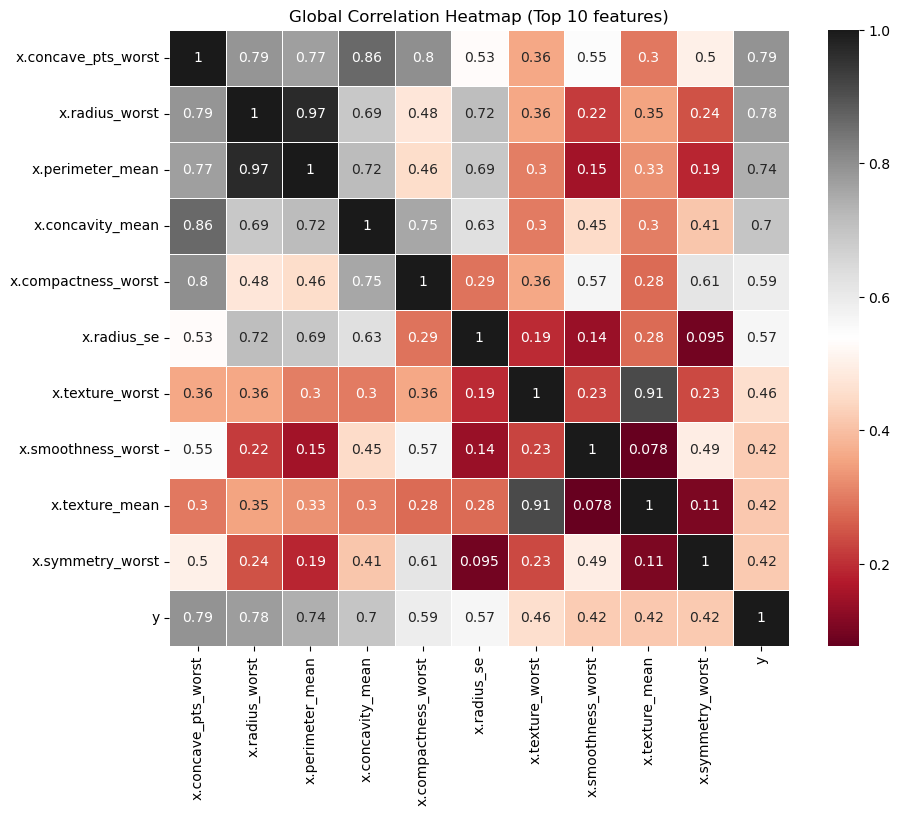

In [31]:
plt.figure(figsize=(10, 8))

# Calculate the correlation matrix for all features
correlation_matrix_full = df_top10.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix_full, annot=True, cmap='RdGy', linewidths=0.5)
plt.title('Global Correlation Heatmap (Top 10 features)')
plt.show()

5.6. Visualization - boxplot

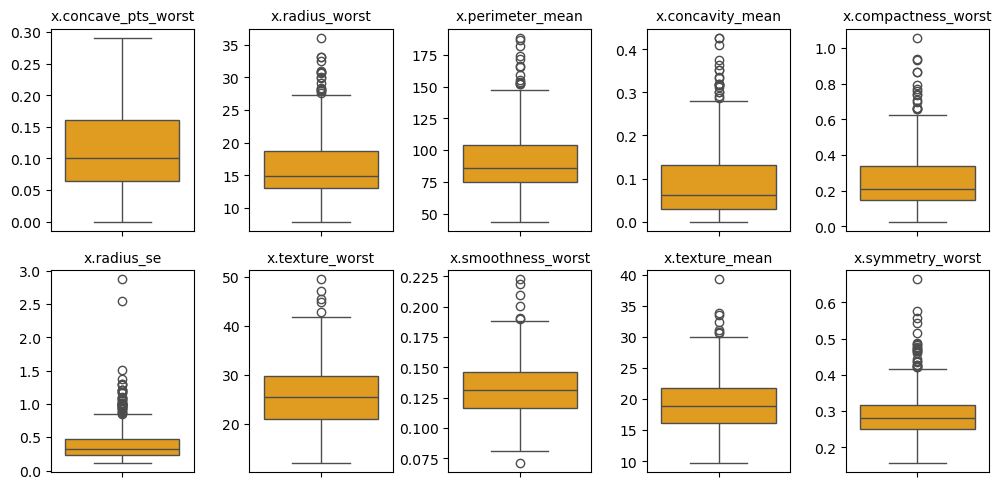

In [32]:
features = [col for col in df_top10.columns if col != 'y']

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten() 
for i, feature in enumerate(features):
    sns.boxplot(y=df[feature], ax=axes[i], color='orange')
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()